In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

# Problem 8: Kernelized linear regression

(-10.0, 10.0)

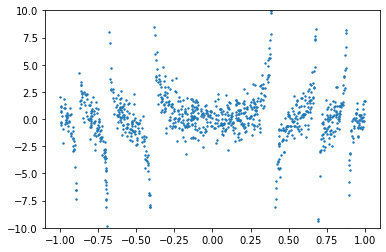

In [2]:
# let us generate some data
m = 1000
x = -1 + 2 * np.random.rand(m)
y = np.tan(10*x**2)+np.random.randn(m)
plt.scatter(x,y,s=2) # s controls the size of the data points
plt.ylim([-10,10])

Your goal is to fit a **Kernelized Linear Regression Model** to the data points, and plot the model.
You will use three kernels

- Gaussian kernel $k(x,z)=e^{-\gamma \|x-z\|^2}$, 
- Sigmoid kernel $k(x,z)=\tanh(\gamma xz^T+r)$, and
- Polynomial kernel $k(x,z)=(1+xz^T)^d$,

where $\gamma$, $r$ and $d$ are parameters (chosen by you).

## Part 1: Gaussian kernel

In [94]:
dist = pairwise_distances(x.reshape(m,1))



gamma = 10
K = np.exp(-gamma*dist**2)
alpha = np.linalg.lstsq(K,y,rcond=None)[0]
alpha.shape

(1000,)

(-20.0, 20.0)

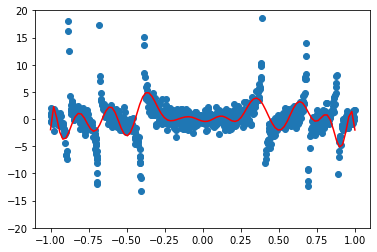

In [95]:
m_plot = 100
x_plot = np.linspace(-1,1,m_plot)
dist_plot = pairwise_distances(x_plot.reshape(m_plot,1),x.reshape(m,1))
K_plot = np.exp(-gamma*dist_plot**2)
y_plot = K_plot.dot(alpha)

plt.scatter(x,y)
plt.plot(x_plot,y_plot,'r')
plt.ylim([-20,20])

## Part 2: Sigmoid kernel

In [88]:
XXT =x.reshape(m,1).dot(x.reshape(1,m))

In [89]:
gamma = 15
r= 1
K = np.tanh(gamma*XXT+r)
alpha = np.linalg.lstsq(K,y,rcond=None)[0]
alpha.shape

(1000,)

(-20.0, 20.0)

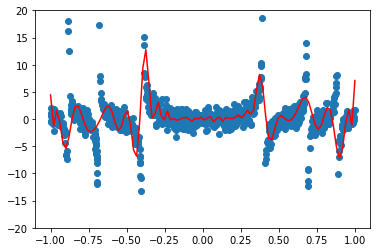

In [91]:
m_plot = 100
x_plot = np.linspace(-1,1,m_plot)
dist_plot = pairwise_distances(x_plot.reshape(m_plot,1),x.reshape(m,1))
X_plot = x_plot.reshape(m_plot,1).dot(x.reshape(1,m))
K_plot = np.tanh(gamma*X_plot+r)
y_plot = K_plot.dot(alpha)

plt.scatter(x,y)
plt.plot(x_plot,y_plot,'r')
plt.ylim([-20,20])

## Part 3: Polynomial kernel

In [92]:
d = 15
K = (1+XXT)**d
alpha = np.linalg.lstsq(K,y,rcond=None)[0]

(-20.0, 20.0)

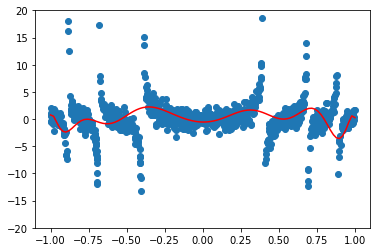

In [93]:
m_plot = 100
x_plot = np.linspace(-1,1,m_plot)
dist_plot = pairwise_distances(x_plot.reshape(m_plot,1),x.reshape(m,1))
X_plot = x_plot.reshape(m_plot,1).dot(x.reshape(1,m))
K_plot = (1+X_plot)**d
y_plot = K_plot.dot(alpha)

plt.scatter(x,y)
plt.plot(x_plot,y_plot,'r')
plt.ylim([-20,20])